## **Agrupamiento**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine

In [3]:
USUARIO = "postgres"
PASSWORD = "1028"
HOST = "localhost"
PUERTO = "5432"
BASE_DATOS = "dw_analisis_criminalidad"

engine = create_engine(
    f"postgresql+psycopg2://{USUARIO}:{PASSWORD}@{HOST}:{PUERTO}/{BASE_DATOS}"
)

print("Conexión creada correctamente.")

Conexión creada correctamente.


### **1. Seleccion y analisis de variables**

#### **1.1 Construccion de matriz de información**

In [9]:
query = """
WITH datos_base AS (
    SELECT
        u.id_ubicacion,
        u.municipio,
        t.fecha,
        t.anio,
        t.mes,
        t.es_fin_semana,
        d.tipo_delito,
        v.genero,
        v.grupo_etario,
        f.cantidad_delitos
    FROM fact_delitos f
    INNER JOIN dim_ubicacion u
        ON f.id_ubicacion = u.id_ubicacion
    INNER JOIN dim_tiempo t
        ON f.id_tiempo = t.id_tiempo
    INNER JOIN dim_delito d
        ON f.id_delito = d.id_delito
    INNER JOIN dim_victima v
        ON f.id_victima = v.id_victima
),

-- 1. MAGNITUD TOTAL
magnitud AS (
    SELECT
        id_ubicacion,
        municipio,
        SUM(cantidad_delitos) AS total_afectaciones
    FROM datos_base
    GROUP BY id_ubicacion, municipio
),

-- 2. VARIABILIDAD ANUAL

afectaciones_anuales AS (
    SELECT
        id_ubicacion,
        municipio,
        anio,
        SUM(cantidad_delitos) AS afectaciones_anuales
    FROM datos_base
    GROUP BY id_ubicacion, municipio, anio
),

variabilidad AS (
    SELECT
        id_ubicacion,
        STDDEV_SAMP(afectaciones_anuales) AS desviacion_anual
    FROM afectaciones_anuales
    GROUP BY id_ubicacion
),

-- 3. PARTICIPACIÓN POR TIPO DE DELITO

delitos AS (
    SELECT
        id_ubicacion,
        municipio,
        SUM(
            CASE
                WHEN tipo_delito = 'Amenazas'
                THEN cantidad_delitos ELSE 0
            END
        ) * 100.0 / SUM(cantidad_delitos) AS pct_amenazas,
        SUM(
            CASE
                WHEN tipo_delito = 'Delitos sexuales'
                THEN cantidad_delitos ELSE 0
            END
        ) * 100.0 / SUM(cantidad_delitos) AS pct_delitos_sexuales,
        SUM(
            CASE
                WHEN tipo_delito = 'Homicidio'
                THEN cantidad_delitos ELSE 0
            END
        ) * 100.0 / SUM(cantidad_delitos) AS pct_homicidios,
        SUM(
            CASE
                WHEN tipo_delito = 'Hurto de motocicletas y automotores'
                THEN cantidad_delitos ELSE 0
            END
        ) * 100.0 / SUM(cantidad_delitos) AS pct_hurto_motocicletas_automotores,
        SUM(
            CASE
                WHEN tipo_delito = 'Hurto a residencias y entidades comerciales'
                THEN cantidad_delitos ELSE 0
            END
        ) * 100.0 / SUM(cantidad_delitos) AS pct_hurto_residencias_comerciales,
        SUM(
            CASE
                WHEN tipo_delito = 'Lesiones personales'
                THEN cantidad_delitos ELSE 0
            END
        ) * 100.0 / SUM(cantidad_delitos) AS pct_lesiones_personales,
        SUM(
            CASE
                WHEN tipo_delito = 'Violencia intrafamiliar'
                THEN cantidad_delitos ELSE 0
            END
        ) * 100.0 / SUM(cantidad_delitos) AS pct_violencia_intrafamiliar
    FROM datos_base
    GROUP BY id_ubicacion, municipio
),

-- 4. TENDENCIA TEMPORAL
-- Pendiente de regresión de las afectaciones anuales

tendencia AS (
    SELECT
        id_ubicacion,
        REGR_SLOPE(afectaciones_anuales, anio) AS tendencia_anual
    FROM afectaciones_anuales
    GROUP BY id_ubicacion
),

--5. FINES DE SEMANA
fin_semana AS (
    SELECT
        id_ubicacion,

        SUM(
            CASE
                WHEN es_fin_semana = TRUE
                THEN cantidad_delitos ELSE 0
            END
        ) * 100.0 / SUM(cantidad_delitos) AS pct_fin_semana

    FROM datos_base
    GROUP BY id_ubicacion
),

-- 6. GÉNERO
genero AS (
    SELECT
        id_ubicacion,
        SUM(
            CASE
                WHEN LOWER(genero) = 'masculino'
                THEN cantidad_delitos ELSE 0
            END
        ) * 100.0 / SUM(cantidad_delitos) AS pct_masculino,
        SUM(
            CASE
                WHEN LOWER(genero) = 'femenino'
                THEN cantidad_delitos ELSE 0
            END
        ) * 100.0 / SUM(cantidad_delitos) AS pct_femenino,
        SUM(
            CASE
                WHEN LOWER(genero) = 'no reportado'
                THEN cantidad_delitos ELSE 0
            END
        ) * 100.0 / SUM(cantidad_delitos) AS pct_genero_no_reportado
    FROM datos_base
    GROUP BY id_ubicacion
),

-- 7. GRUPO ETARIO
edad AS (
    SELECT
        id_ubicacion,

        SUM(
            CASE
                WHEN grupo_etario = 'Adolescentes'
                THEN cantidad_delitos ELSE 0
            END
        ) * 100.0 / SUM(cantidad_delitos) AS pct_edad_adolescentes,

        SUM(
            CASE
                WHEN grupo_etario = 'Menores'
                THEN cantidad_delitos ELSE 0
            END
        ) * 100.0 / SUM(cantidad_delitos) AS pct_edad_menores,

        SUM(
            CASE
                WHEN grupo_etario = 'Adultos'
                THEN cantidad_delitos ELSE 0
            END
        ) * 100.0 / SUM(cantidad_delitos) AS pct_edad_adultos,

        SUM(
            CASE
                WHEN grupo_etario = 'No reportado'
                THEN cantidad_delitos ELSE 0
            END
        ) * 100.0 / SUM(cantidad_delitos) AS pct_edad_no_reportado


    FROM datos_base
    GROUP BY id_ubicacion
)

-- MATRIZ FINAL
SELECT
    m.id_ubicacion,
    m.municipio,

    -- Magnitud
    m.total_afectaciones,
    v.desviacion_anual,

    -- Tipo de delito
    d.pct_amenazas,
    d.pct_delitos_sexuales,
    d.pct_homicidios,
    d.pct_hurto_motocicletas_automotores,
    d.pct_hurto_residencias_comerciales,
    d.pct_lesiones_personales,
    d.pct_violencia_intrafamiliar,

    -- Temporal
    t.tendencia_anual,
    fs.pct_fin_semana,

    -- Género
    g.pct_masculino,
    g.pct_femenino,
    g.pct_genero_no_reportado,

    -- Edad
    e.pct_edad_adolescentes,
    e.pct_edad_menores,
    e.pct_edad_adultos,
    e.pct_edad_no_reportado

FROM magnitud m

LEFT JOIN variabilidad v
    ON m.id_ubicacion = v.id_ubicacion

LEFT JOIN delitos d
    ON m.id_ubicacion = d.id_ubicacion

LEFT JOIN tendencia t
    ON m.id_ubicacion = t.id_ubicacion

LEFT JOIN fin_semana fs
    ON m.id_ubicacion = fs.id_ubicacion

LEFT JOIN genero g
    ON m.id_ubicacion = g.id_ubicacion

LEFT JOIN edad e
    ON m.id_ubicacion = e.id_ubicacion

ORDER BY m.municipio;
"""
df_matriz_variables = pd.read_sql(query, engine)
df_matriz_variables.head(20)

,id_ubicacion,municipio,total_afectaciones,desviacion_anual,pct_amenazas,pct_delitos_sexuales,pct_homicidios,pct_hurto_motocicletas_automotores,pct_hurto_residencias_comerciales,pct_lesiones_personales,pct_violencia_intrafamiliar,tendencia_anual,pct_fin_semana,pct_masculino,pct_femenino,pct_genero_no_reportado,pct_edad_adolescentes,pct_edad_menores,pct_edad_adultos,pct_edad_no_reportado
0,1,Abejorral,1056,36.019439,5.965909,13.446970,5.681818,3.977273,11.174242,41.950758,17.803030,7.818182,33.522727,50.946970,39.299242,9.753788,5.113636,3.503788,89.299242,2.083333
1,2,Abriaquí,33,1.885092,18.181818,33.333333,3.030303,3.030303,9.090909,15.151515,18.181818,-0.409766,39.393939,36.363636,54.545455,9.090909,12.121212,9.090909,78.787879,0.000000
2,3,Alejandría,353,15.254210,5.949008,10.764873,2.266289,3.116147,6.798867,43.909348,27.195467,3.809091,34.277620,44.475921,49.575071,5.949008,5.099150,3.399433,90.084986,1.416431
3,4,Amagá,2483,68.202773,9.585179,8.296416,5.678615,7.128474,7.974225,42.368103,18.968989,7.827273,36.246476,45.348369,47.080145,7.571486,5.396698,2.577527,90.213451,1.812324
4,5,Amalfi,1456,45.405446,9.890110,9.134615,10.714286,7.486264,7.486264,37.843407,17.445055,-0.663636,34.752747,44.848901,47.733516,7.417582,3.434066,2.335165,93.681319,0.549451
5,6,Andes,3414,78.147646,7.147042,10.105448,10.632689,4.920914,5.418864,35.559461,26.215583,0.790909,34.007030,46.162859,48.681898,5.155243,5.330990,2.665495,90.861160,1.142355
6,7,Angelópolis,553,14.050558,8.318264,11.392405,7.775769,3.435805,5.605787,25.497288,37.974684,2.036364,30.560579,42.495479,51.717902,5.786618,5.063291,3.435805,90.958409,0.542495
7,8,Angostura,722,20.175593,13.019391,9.279778,11.911357,5.124654,6.232687,32.271468,22.160665,-1.727273,34.072022,48.753463,45.013850,6.232687,6.371191,3.878116,87.811634,1.939058
8,9,Anorí,1273,36.929909,10.683425,9.033778,16.339356,3.063629,7.541241,35.506677,17.831893,8.063636,32.443048,45.483111,46.975648,7.541241,4.163394,2.827965,92.144540,0.864101
9,10,Anza,360,13.565330,12.777778,10.833333,9.166667,3.888889,7.500000,36.388889,19.444444,0.845455,34.722222,42.777778,51.388889,5.833333,4.166667,6.111111,88.611111,1.111111


In [10]:
import pandas as pd
import numpy as np

df = df_matriz_variables.copy()

variables = [
    "total_afectaciones",
    "desviacion_anual",
    "pct_amenazas",
    "pct_delitos_sexuales",
    "pct_homicidios",
    "pct_hurto_motocicletas_automotores",
    "pct_hurto_residencias_comerciales",
    "pct_lesiones_personales",
    "pct_violencia_intrafamiliar",
    "tendencia_anual",
    "pct_fin_semana",
    "pct_masculino",
    "pct_femenino",
    "pct_genero_no_reportado",
    "pct_edad_adolescentes",
    "pct_edad_menores",
    "pct_edad_adultos",
    "pct_edad_no_reportado"
]

resumen = df[variables].describe().T

resumen["desviacion"] = df[variables].std()
resumen["asimetría"] = df[variables].skew()

resumen = resumen[
    [
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "asimetría"
    ]
]

resumen.round(3)

,mean,std,min,25%,50%,75%,max,asimetría
total_afectaciones,4844.688,28337.054,33.000,483.000,996.000,2037.000,314391.000,10.704
desviacion_anual,97.929,466.202,1.885,16.449,29.053,52.265,5116.367,10.295
pct_amenazas,9.474,4.903,2.692,5.617,9.113,11.873,33.333,1.556
pct_delitos_sexuales,10.389,4.243,4.257,8.035,9.732,11.950,33.333,2.311
pct_homicidios,8.948,6.068,0.719,4.856,7.453,11.443,32.734,1.458
pct_hurto_motocicletas_automotores,7.064,4.587,0.000,4.040,6.130,9.483,28.454,1.575
pct_hurto_residencias_comerciales,9.541,3.640,3.200,6.979,8.879,11.159,21.538,1.096
pct_lesiones_personales,34.878,7.338,15.152,29.596,35.714,40.275,52.681,-0.276
pct_violencia_intrafamiliar,19.706,5.650,8.914,16.147,18.723,22.512,37.975,0.595
tendencia_anual,17.677,105.664,-10.909,0.764,3.182,7.800,1158.173,10.388


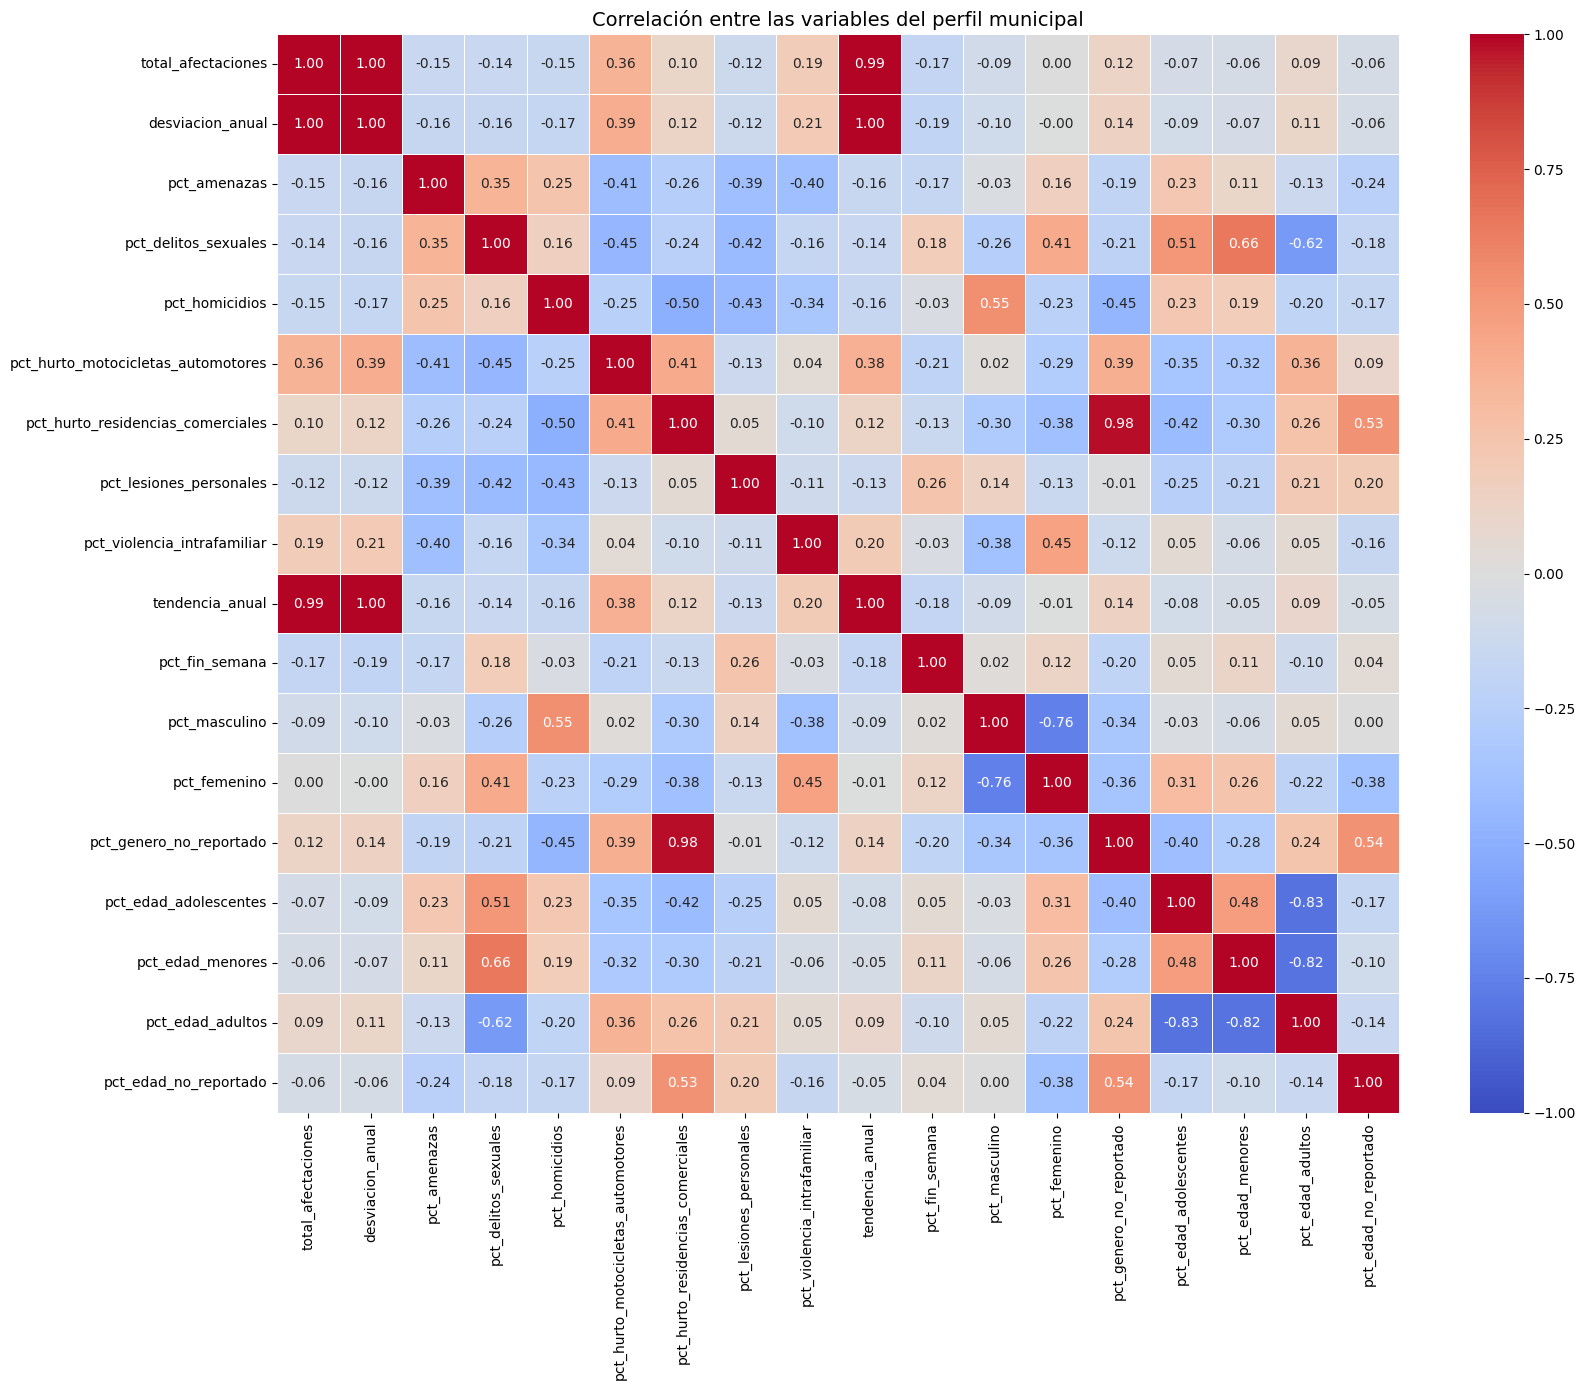

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df[variables].corr()

plt.figure(figsize=(17, 14))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title(
    "Correlación entre las variables del perfil municipal",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [ ]:
corr

In [13]:
pares = []

for i, var1 in enumerate(variables):
    for var2 in variables[i+1:]:

        r = corr.loc[var1, var2]

        pares.append({
            "variable_1": var1,
            "variable_2": var2,
            "correlacion": r,
            "valor_absoluto": abs(r)
        })

pares_corr = pd.DataFrame(pares)

pares_corr = pares_corr.sort_values(
    "valor_absoluto",
    ascending=False
)

pares_corr.head(20).round(3)

,variable_1,variable_2,correlacion,valor_absoluto
0,total_afectaciones,desviacion_anual,0.997,0.997
24,desviacion_anual,tendencia_anual,0.996,0.996
8,total_afectaciones,tendencia_anual,0.994,0.994
93,pct_hurto_residencias_comerciales,pct_genero_no_reportado,0.978,0.978
148,pct_edad_adolescentes,pct_edad_adultos,-0.826,0.826
150,pct_edad_menores,pct_edad_adultos,-0.818,0.818
132,pct_masculino,pct_femenino,-0.755,0.755
59,pct_delitos_sexuales,pct_edad_menores,0.655,0.655
60,pct_delitos_sexuales,pct_edad_adultos,-0.622,0.622
68,pct_homicidios,pct_masculino,0.551,0.551
